# Step-by-step demo of NEDAS using the vort2d model

## Load NEDAS and dependencies

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from NEDAS import get_scheme
from NEDAS.config import Config

## Initialize configuration and main scheme

In [8]:
config = Config(config_file="vort2d/config.yml")

config.debug = False
config.nproc = 1
config.io_mode = 'offline'

In [29]:
scheme = get_scheme(config)

model = scheme.c.models['vort2d']
dataset = scheme.c.datasets['vort2d']

## Prepare truth

check nc files in vort2d/truth

In [12]:
%rm -rf vort2d/truth/*

In [13]:
scheme.prepare_truth()


Generate vort2d truth ─────────────────────────── ✅    22.80s                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            


In [14]:
scheme.c.time = scheme.c.config.time_start

truth_state = []
while scheme.c.time < scheme.c.config.time_end:
    truth_state.append(model.read_var(tag='truth', name='velocity', member=None, time=scheme.c.time))
    scheme.c.time = scheme.c.next_time

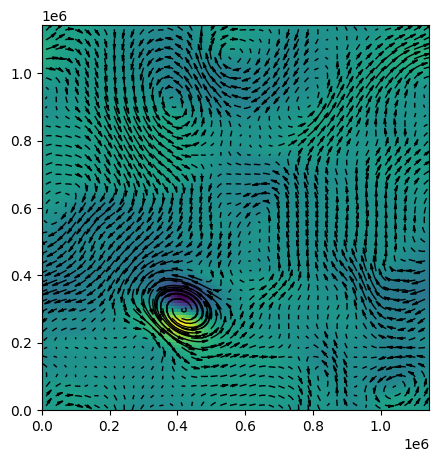

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
grid = scheme.c.grid
n = 10
grid.plot_field(ax, truth_state[n][0])
grid.plot_vectors(ax, truth_state[n])

In [6]:
model = scheme.c.models['vort2d']
dataset = scheme.c.datasets['vort2d']

In [ ]:
model.load_memory('truth')

In [ ]:
model.memory

In [ ]:
scheme.c.time = scheme.c.config.time_start

truth_state = []
while scheme.c.time < scheme.c.config.time_end:
    truth_state.append(model.read_var_from_memory(tag='truth', name='velocity', time=scheme.c.time, member=None))
    scheme.c.time = scheme.c.next_time


In [ ]:
fig, ax = plt.subplots(1,1,figsize=(5, 5))

n = 10

# plot prior/post ensemble
#for m in range(scheme.c.nens):
#    ax.plot(scheme.c.grid.x, post_state[n][m], color='c')

# plot obs
#ax.plot(obs_x[n], obs_val[n], 'x', color='r', markersize=10)

# plot truth
scheme.c.grid.plot_vectors(ax, truth_state[n])

#ax.set_xlim(0, scheme.c.grid.Lx)
#ax.set_ylim(-2, 5)